# Alternative 2: potential hydrological connectivity (Mole Creek)

This notebook tests a simple, transparent combination of three kinds of evidence:

1. DEM flow accumulation as a relative indicator of potential surface-water concentration.
2. LIST `Watercourse` lines as independent evidence of mapped surface drainage.
3. Karst Atlas `KPROXCATCH` as evidence that a cell belongs to a mapped proximal catchment associated with karst.

The result is interpreted as **relative potential for surface water to be concentrated and connected to mapped karst catchments**. Flow accumulation is not discharge or groundwater flow, and a mapped Watercourse is not a measure of flow volume. `KPROXCATCH` letters are used only as presence/absence; they are not converted to scores. `KDISTCATCH` is not used.

The notebook reads the existing DEM and flow-accumulation raster. It creates new, distinctly named alternative rasters in `Output_data`; it does not overwrite the existing hydrological model outputs.


## 1. Inputs, grid, and output names

The workflow uses the project's `Input_data/Hydline` municipality files and the Stage 2 karst GeoPackage. No merged Watercourse GeoPackage is stored in `Output_data`, so this self-contained notebook reads the 29 source files and merges only records where `HYDLNTY1` is exactly `Watercourse`. Other Hydline categories are excluded.

The existing flow-accumulation raster is the grid template. The notebook checks that it matches the existing 25 m Mole Creek DEM. All four alternative rasters use this exact grid and use 255 as NoData outside valid DEM cells.


In [1]:
from pathlib import Path
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from rasterio.features import rasterize

# Resolve the project root whether Jupyter starts in the repository or notebooks folder.
working_dir = Path.cwd()
project_root = working_dir.parent if working_dir.name == "notebooks" else working_dir

# Use an inherited variable first; otherwise read only AT3_DATA_DIR from the project .env.
data_dir_value = os.environ.get("AT3_DATA_DIR")
if not data_dir_value:
    env_file = project_root / ".env"
    if env_file.exists():
        for line in env_file.read_text(encoding="utf-8-sig").splitlines():
            entry = line.strip()
            if entry.startswith("AT3_DATA_DIR="):
                data_dir_value = entry.split("=", 1)[1].strip().strip("\"").strip("'")
                break

data_path = Path(data_dir_value).expanduser() if data_dir_value else project_root / "data"
if not data_path.is_absolute():
    data_path = (project_root / data_path).resolve()

input_path = data_path / "Input_data"
output_path = data_path / "Output_data"
dem_path = output_path / "dem_mc_EPSG7855.tif"
flow_accumulation_path = output_path / "flow_accum_mc_EPSG7855.tif"
karst_atlas_path = output_path / "karst_mc_susceptibility_EPSG7855.gpkg"
hydline_root = input_path / "Hydline"

# New names keep these alternative results separate from existing Stage 3 rasters.
output_paths = {
    "dem_drainage_class": output_path / "dem_drainage_class_mc_EPSG7855_alt2.tif",
    "watercourse_presence": output_path / "watercourse_presence_mc_EPSG7855_alt2.tif",
    "kproxcatch_presence": output_path / "kproxcatch_presence_mc_EPSG7855_alt2.tif",
    "potential_connectivity": output_path / "potential_hydrological_connectivity_mc_EPSG7855_alt2.tif",
}


## 2. Relative DEM drainage classes

The flow-accumulation values are divided into three equal-frequency groups using the 33? and 66? percentiles of valid cells (tertiles). This gives relative Low, Moderate, and High classes for this study area, rather than applying a fixed channel threshold. Because the input is integer cell counts, ties at the quantile breaks can make class sizes unequal; the measured breaks and resulting counts are printed below.

For the current raster, the expected breaks are 3 and 10 upstream cells. These are quantile results for this DEM, not universal hydrological thresholds.


In [2]:
with rasterio.open(dem_path) as dem_src:
    dem_masked = dem_src.read(1, masked=True)
    dem_transform = dem_src.transform
    dem_crs = dem_src.crs
    dem_shape = (dem_src.height, dem_src.width)

with rasterio.open(flow_accumulation_path) as flow_src:
    flow_masked = flow_src.read(1, masked=True)
    flow_transform = flow_src.transform
    flow_crs = flow_src.crs
    flow_profile = flow_src.profile.copy()

if dem_shape != flow_masked.shape or dem_transform != flow_transform or dem_crs != flow_crs:
    raise ValueError("The existing DEM and flow-accumulation raster are not aligned")

valid_cells = ~(
    np.ma.getmaskarray(dem_masked) | np.ma.getmaskarray(flow_masked)
)
flow_values = flow_masked.data[valid_cells]
q_low, q_high = np.quantile(flow_values, [1 / 3, 2 / 3])

# Class codes: 1 = Low, 2 = Moderate, 3 = High, 255 = NoData.
dem_drainage_class = np.full(flow_masked.shape, 255, dtype="uint8")
valid_flow = flow_masked.data
low_cells = valid_cells & (valid_flow <= q_low)
moderate_cells = valid_cells & (valid_flow > q_low) & (valid_flow <= q_high)
high_cells = valid_cells & (valid_flow > q_high)
dem_drainage_class[low_cells] = 1
dem_drainage_class[moderate_cells] = 2
dem_drainage_class[high_cells] = 3

print(f"Valid cells used for quantiles: {len(flow_values):,}")
print(f"Tertile breaks: Q33.3 = {q_low:g}; Q66.7 = {q_high:g} upstream cells")
print(
    "Class cell counts (Low, Moderate, High): "
    f"{int(low_cells.sum()):,}, {int(moderate_cells.sum()):,}, {int(high_cells.sum()):,}"
)


Valid cells used for quantiles: 1,848,410
Tertile breaks: Q33.3 = 3; Q66.7 = 10 upstream cells
Class cell counts (Low, Moderate, High): 720,256, 543,865, 584,289


## 3. Rasterise LIST Watercourses

Only `HYDLNTY1 == "Watercourse"` is retained. These lines become a binary presence layer: 1 where a mapped line crosses a cell, 0 elsewhere. `all_touched=True` burns every 25 m cell touched by a line so narrow mapped channels are not lost just because they miss a cell centre. This layer is independent evidence of mapped drainage; it is not assigned a flow-volume score.


In [3]:
hydline_files = sorted(hydline_root.rglob("list_hydline_*.shp"))
if not hydline_files:
    raise FileNotFoundError(f"No LIST Hydline shapefiles found under {hydline_root}")

watercourse_parts = []
for shapefile in hydline_files:
    features = gpd.read_file(shapefile)
    if "HYDLNTY1" not in features.columns:
        continue
    watercourses = features.loc[features["HYDLNTY1"].eq("Watercourse")].copy()
    watercourses = watercourses.loc[
        watercourses.geometry.notna() & ~watercourses.geometry.is_empty
    ]
    if watercourses.empty:
        continue
    if watercourses.crs is None:
        raise ValueError(f"Watercourse features have no CRS: {shapefile}")
    watercourse_parts.append(watercourses.to_crs(flow_crs))

if not watercourse_parts:
    raise ValueError("No HYDLNTY1 == 'Watercourse' features were found")

watercourses_alt2 = gpd.GeoDataFrame(
    pd.concat(watercourse_parts, ignore_index=True),
    crs=flow_crs,
)
watercourse_geometries = [
    geometry for geometry in watercourses_alt2.geometry
    if geometry is not None and not geometry.is_empty
]
watercourse_presence = rasterize(
    ((geometry, 1) for geometry in watercourse_geometries),
    out_shape=flow_masked.shape,
    transform=flow_transform,
    fill=0,
    dtype="uint8",
    all_touched=True,
)
watercourse_presence[~valid_cells] = 255
print(f"Hydline files read: {len(hydline_files)}")
print(f"Watercourse features merged: {len(watercourses_alt2):,}")
print(f"Cells with a mapped Watercourse: {int((watercourse_presence == 1).sum()):,}")


Hydline files read: 29
Watercourse features merged: 552,028
Cells with a mapped Watercourse: 99,258


## 4. Rasterise `KPROXCATCH` as presence/absence

The Stage 2 Karst Atlas GeoPackage retains the original `KPROXCATCH` field. A non-zero, non-empty value means a mapped proximal allogenic catchment; its letter is not a strength score. The raster uses 1 for presence and 0 for no mapped proximal catchment, on the flow-accumulation grid. `KDISTCATCH` is not used.


In [4]:
karst_atlas = gpd.read_file(karst_atlas_path)
if "KPROXCATCH" not in karst_atlas.columns:
    raise KeyError(f"KPROXCATCH field not found in {karst_atlas_path}")
if karst_atlas.crs is None:
    raise ValueError("Karst Atlas polygons have no CRS")

karst_atlas = karst_atlas.loc[
    karst_atlas.geom_type.isin(["Polygon", "MultiPolygon"])
].copy()
if karst_atlas.crs != flow_crs:
    karst_atlas = karst_atlas.to_crs(flow_crs)

kprox_values = karst_atlas["KPROXCATCH"].astype("string").str.strip()
kprox_present = karst_atlas.loc[
    kprox_values.notna() & kprox_values.ne("") & kprox_values.ne("0")
]
kprox_geometries = [
    geometry for geometry in kprox_present.geometry
    if geometry is not None and not geometry.is_empty
]
kproxcatch_presence = rasterize(
    ((geometry, 1) for geometry in kprox_geometries),
    out_shape=flow_masked.shape,
    transform=flow_transform,
    fill=0,
    dtype="uint8",
    all_touched=True,
)
kproxcatch_presence[~valid_cells] = 255
print(f"Karst Atlas polygons: {len(karst_atlas):,}")
print(f"Polygons with non-zero KPROXCATCH: {len(kprox_present):,}")
print(f"Cells in mapped proximal catchments: {int((kproxcatch_presence == 1).sum()):,}")


Karst Atlas polygons: 90
Polygons with non-zero KPROXCATCH: 24
Cells in mapped proximal catchments: 849,741


## 5. Proposed classification table

The output codes below are categorical labels, **not values to add or scores with equal numerical spacing**. The rules retain DEM-only drainage potential and mapped Watercourses even where one of the other indicators is absent. The final class represents the strongest combined evidence when all three signals are present.

| Code | DEM drainage class | Watercourse | `KPROXCATCH` | Interpretation |
|---:|---|---|---|---|
| 0 | Low | No | No | Low surface signal; no mapped proximal catchment |
| 1 | Moderate | No | No | Moderate DEM drainage potential only |
| 2 | High | No | No | High DEM drainage potential; channel not mapped |
| 3 | Any | Yes | No | Mapped surface drainage; no mapped proximal catchment |
| 4 | Low | No | Yes | Mapped proximal catchment; weak DEM/channel corroboration |
| 5 | Moderate | No | Yes | Moderate DEM potential within mapped proximal catchment |
| 6 | High | No | Yes | High DEM potential in mapped proximal catchment; channel not mapped |
| 7 | Low or Moderate | Yes | Yes | Mapped Watercourse in a proximal catchment; lower DEM class |
| 8 | High | Yes | Yes | **Strongest evidence:** high DEM drainage, mapped Watercourse, and `KPROXCATCH` |



In [5]:
# Apply the table above. No input values are added together.
watercourse_present = watercourse_presence == 1
kprox_present_cells = kproxcatch_presence == 1
final_connectivity = np.full(flow_masked.shape, 255, dtype="uint8")

classification_rules = [
    (low_cells & ~watercourse_present & ~kprox_present_cells, 0),
    (moderate_cells & ~watercourse_present & ~kprox_present_cells, 1),
    (high_cells & ~watercourse_present & ~kprox_present_cells, 2),
    (watercourse_present & ~kprox_present_cells, 3),
    (low_cells & ~watercourse_present & kprox_present_cells, 4),
    (moderate_cells & ~watercourse_present & kprox_present_cells, 5),
    (high_cells & ~watercourse_present & kprox_present_cells, 6),
    (
        (low_cells | moderate_cells) & watercourse_present & kprox_present_cells,
        7,
    ),
    (high_cells & watercourse_present & kprox_present_cells, 8),
]
for condition, class_code in classification_rules:
    final_connectivity[valid_cells & condition] = class_code

if np.any(valid_cells & (final_connectivity == 255)):
    raise ValueError("The classification table did not assign every valid cell")

# Write outputs only when none exist; never overwrite an existing raster.
rasters_to_write = {
    "dem_drainage_class": dem_drainage_class,
    "watercourse_presence": watercourse_presence,
    "kproxcatch_presence": kproxcatch_presence,
    "potential_connectivity": final_connectivity,
}
existing_outputs = [path for path in output_paths.values() if path.exists()]

if existing_outputs and len(existing_outputs) != len(output_paths):
    raise FileExistsError(
        "Only some alternative rasters exist. No files were written; resolve the partial output set first: "
        + ", ".join(str(path) for path in existing_outputs)
    )
elif existing_outputs:
    print("All four alternative rasters already exist; leaving them unchanged:")
    for name, path in output_paths.items():
        print(f"  {name}: {path.name}")
else:
    output_profile = flow_profile.copy()
    output_profile.update(driver="GTiff", count=1, dtype="uint8", nodata=255)
    for name, array in rasters_to_write.items():
        with rasterio.open(output_paths[name], "w", **output_profile) as dst:
            dst.write(array, 1)
            dst.update_tags(method="Alternative hydrological connectivity 2")

    print("New alternative rasters written:")
    for name, path in output_paths.items():
        print(f"  {name}: {path.name}")


New alternative rasters written:
  dem_drainage_class: dem_drainage_class_mc_EPSG7855_alt2.tif
  watercourse_presence: watercourse_presence_mc_EPSG7855_alt2.tif
  kproxcatch_presence: kproxcatch_presence_mc_EPSG7855_alt2.tif
  potential_connectivity: potential_hydrological_connectivity_mc_EPSG7855_alt2.tif


## 6. Maps

The first map shows the final categorical classification. The second overlays the three input indicators: DEM drainage classes as the background, `KPROXCATCH` cells in magenta, and Watercourse cells in blue. Both maps use the flow raster's projected grid and coordinate extent.


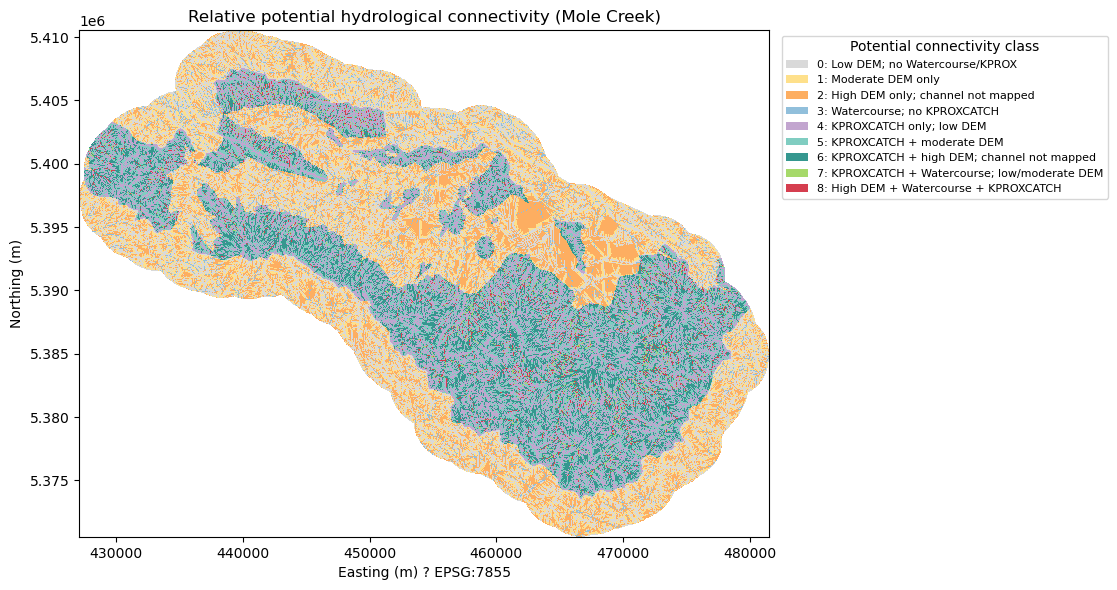

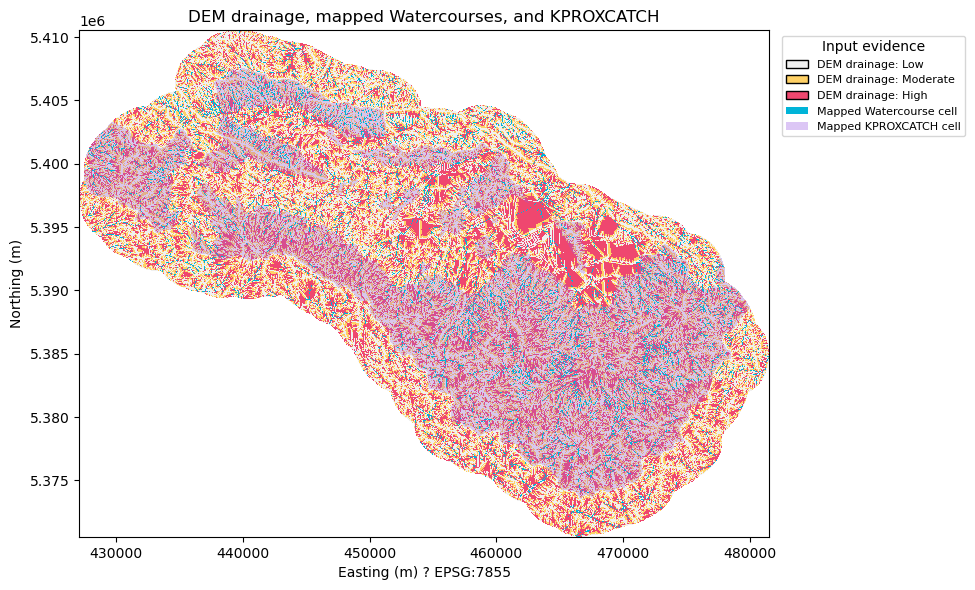

In [6]:
flow_height, flow_width = flow_masked.shape
left, bottom, right, top = rasterio.transform.array_bounds(
    flow_height, flow_width, flow_transform
)
raster_extent = (left, right, bottom, top)

final_labels = {
    0: "Low DEM; no Watercourse/KPROX",
    1: "Moderate DEM only",
    2: "High DEM only; channel not mapped",
    3: "Watercourse; no KPROXCATCH",
    4: "KPROXCATCH only; low DEM",
    5: "KPROXCATCH + moderate DEM",
    6: "KPROXCATCH + high DEM; channel not mapped",
    7: "KPROXCATCH + Watercourse; low/moderate DEM",
    8: "High DEM + Watercourse + KPROXCATCH",
}
final_colors = [
    "#d9d9d9", "#fee08b", "#fdae61", "#91bfdb", "#c2a5cf",
    "#80cdc1", "#35978f", "#a6d96a", "#d53e4f",
]
final_cmap = ListedColormap(final_colors)
final_display = np.ma.masked_equal(final_connectivity, 255)

fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(
    final_display,
    extent=raster_extent,
    origin="upper",
    cmap=final_cmap,
    vmin=-0.5,
    vmax=8.5,
    interpolation="nearest",
)
final_handles = [
    Patch(facecolor=final_colors[code], label=f"{code}: {label}")
    for code, label in final_labels.items()
]
ax.legend(handles=final_handles, title="Potential connectivity class", loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
ax.set_title("Relative potential hydrological connectivity (Mole Creek)")
ax.set_xlabel(f"Easting (m) ? {flow_crs}")
ax.set_ylabel("Northing (m)")
ax.set_aspect("equal", adjustable="box")
fig.subplots_adjust(right=0.70)
plt.show()

# Combined view of the input evidence, not a numerical combination.
flow_colors = ["#f0f0f0", "#ffd166", "#ef476f"]
flow_display = np.ma.masked_equal(dem_drainage_class, 255)
kprox_display = np.ma.masked_where(kproxcatch_presence != 1, kproxcatch_presence)
watercourse_display = np.ma.masked_where(watercourse_presence != 1, watercourse_presence)

fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(
    flow_display,
    extent=raster_extent,
    origin="upper",
    cmap=ListedColormap(flow_colors),
    vmin=1,
    vmax=3,
    interpolation="nearest",
)
ax.imshow(
    kprox_display,
    extent=raster_extent,
    origin="upper",
    cmap=ListedColormap(["#9b5de5"]),
    alpha=0.28,
    interpolation="nearest",
)
ax.imshow(
    watercourse_display,
    extent=raster_extent,
    origin="upper",
    cmap=ListedColormap(["#00b4d8"]),
    interpolation="nearest",
)
input_handles = [
    Patch(facecolor=flow_colors[0], edgecolor="black", label="DEM drainage: Low"),
    Patch(facecolor=flow_colors[1], edgecolor="black", label="DEM drainage: Moderate"),
    Patch(facecolor=flow_colors[2], edgecolor="black", label="DEM drainage: High"),
    Patch(facecolor="#00b4d8", label="Mapped Watercourse cell"),
    Patch(facecolor="#9b5de5", alpha=0.35, label="Mapped KPROXCATCH cell"),
]
ax.legend(handles=input_handles, title="Input evidence", loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
ax.set_title("DEM drainage, mapped Watercourses, and KPROXCATCH")
ax.set_xlabel(f"Easting (m) ? {flow_crs}")
ax.set_ylabel("Northing (m)")
ax.set_aspect("equal", adjustable="box")
fig.subplots_adjust(right=0.70)
plt.show()


## Interpretation and limits

The map shows **relative potential for surface water to be concentrated and connected to mapped karst catchments**. High flow accumulation without a Watercourse remains potential drainage (classes 2 or 6); a Watercourse is retained even when DEM accumulation is Low (classes 3 or 7). Class 8 is the strongest combined evidence under the table above.

The D8 accumulation raster is based on the existing depression-filled DEM and indicates relative upslope cell contribution. It is not measured flow, discharge, or groundwater movement. Watercourse presence is binary evidence of mapped drainage, not flow magnitude. `KPROXCATCH` indicates mapped proximal catchment presence; it does not establish an underground flow path for every pixel.


## Outputs for ELVIS

The following cell exports the existing Mole Creek study boundary as an ESRI Shapefile in EPSG:4326, suitable as an area-of-interest boundary for an ELVIS LiDAR search. It reads the existing EPSG:7855 GeoPackage and writes the shapefile and its companion files into `Output_data/ELVIS_mole_creek_boundary`. It does not alter the source boundary or any hydrological outputs.


In [ ]:
# Resolve the output directory here so this export cell also works on its own.
from pathlib import Path
import os
import geopandas as gpd
import zipfile

working_dir = Path.cwd()
project_root = working_dir.parent if working_dir.name == "notebooks" else working_dir
data_dir_value = os.environ.get("AT3_DATA_DIR")
if not data_dir_value:
    env_file = project_root / ".env"
    if env_file.exists():
        for line in env_file.read_text(encoding="utf-8-sig").splitlines():
            entry = line.strip()
            if entry.startswith("AT3_DATA_DIR="):
                data_dir_value = entry.split("=", 1)[1].strip().strip("\"").strip("'")
                break
data_path = Path(data_dir_value).expanduser() if data_dir_value else project_root / "data"
if not data_path.is_absolute():
    data_path = (project_root / data_path).resolve()
output_path = data_path / "Output_data"

# Split the full Mole Creek bounding rectangle into two ELVIS area-of-interest shapefiles.
mole_creek_boundary_path = output_path / "mole_creek_bounding_box_EPSG7855.gpkg"
elvis_boundary_folder = output_path / "ELVIS_mole_creek_boundary"
elvis_boundary_folder.mkdir(parents=True, exist_ok=True)
elvis_boundary_paths = [
    elvis_boundary_folder / f"mole_creek_bounding_box_EPSG4326_for_ELVIS_25m_overlap_part_{part}.shp"
    for part in (1, 2)
]

if not mole_creek_boundary_path.exists():
    raise FileNotFoundError(f"Mole Creek boundary not found: {mole_creek_boundary_path}")

mole_creek_boundary = gpd.read_file(mole_creek_boundary_path)
if mole_creek_boundary.crs is None:
    raise ValueError("The Mole Creek boundary has no CRS and cannot be reprojected safely")

from shapely.geometry import box

# Split the rectangle in the projected source CRS so the shared overlap is exactly 25 m.
mole_creek_boundary_projected = mole_creek_boundary.to_crs("EPSG:7855")
west_m, south_m, east_m, north_m = mole_creek_boundary_projected.total_bounds
overlap_m = 25.0
half_overlap_m = overlap_m / 2.0

if east_m - west_m >= north_m - south_m:
    midpoint_m = (west_m + east_m) / 2
    part_geometries_projected = [
        box(west_m, south_m, midpoint_m + half_overlap_m, north_m),
        box(midpoint_m - half_overlap_m, south_m, east_m, north_m),
    ]
else:
    midpoint_m = (south_m + north_m) / 2
    part_geometries_projected = [
        box(west_m, south_m, east_m, midpoint_m + half_overlap_m),
        box(west_m, midpoint_m - half_overlap_m, east_m, north_m),
    ]

shapefile_extensions = (".shp", ".shx", ".dbf", ".prj", ".cpg")

for part_number, (part_geometry, part_path) in enumerate(zip(part_geometries_projected, elvis_boundary_paths), start=1):
    part_boundary = gpd.GeoDataFrame(
        {"name": [f"Mole Creek bounding rectangle part {part_number}"]},
        geometry=[part_geometry],
        crs="EPSG:7855",
    ).to_crs("EPSG:4326")
    part_boundary.to_file(
        part_path,
        driver="ESRI Shapefile",
        index=False,
        encoding="UTF-8",
    )

    # Package this shapefile and its companion files together for ELVIS.
    zip_path = part_path.with_suffix(".zip")
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as archive:
        for extension in shapefile_extensions:
            component = part_path.with_suffix(extension)
            if component.exists():
                archive.write(component, arcname=component.name)
    print(f"Wrote shapefile: {part_path}")
    print(f"Wrote ZIP: {zip_path}")
print(f"Output CRS: {part_boundary.crs}")


## Prepare a 2 m Mole Creek DEM

This section checks the two source GeoTIFFs, reports their overlap and elevation agreement, then creates a new DEM in EPSG:7855. The tiles are mosaicked and reprojected directly onto one approximately 2 m grid, then clipped to the existing buffered Mole Creek polygon created by `00_bounding_boxes` (`mole_creek_bounding_box_EPSG7855.gpkg`). The polygon already includes the project buffer, so no additional buffer is added.

Bilinear resampling is used for reprojection because elevation is a continuous surface; it estimates values between source pixel centres and avoids the blocky shifts nearest-neighbour resampling can introduce. A 2 m output resolution preserves the practical detail of the source data. The output is masked to the polygon and may include NoData pixels outside its boundary within the rectangular raster extent. The source rasters, boundary and existing 25 m DEM are read only. The new file is `dem_mc_2m_EPSG7855.tif`; this cell refuses to overwrite an existing file with that name.

In [8]:
# Resolve the project data directory, using AT3_DATA_DIR from the environment or .env.
from pathlib import Path
import os
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.windows import Window
from osgeo import gdal

working_dir = Path.cwd()
project_root = working_dir.parent if working_dir.name == "notebooks" else working_dir
data_dir_value = os.environ.get("AT3_DATA_DIR")
if not data_dir_value:
    env_file = project_root / ".env"
    if env_file.exists():
        for line in env_file.read_text(encoding="utf-8-sig").splitlines():
            entry = line.strip()
            if entry.startswith("AT3_DATA_DIR="):
                data_dir_value = entry.split("=", 1)[1].strip().strip('"').strip("'")
                break

data_path = Path(data_dir_value).expanduser() if data_dir_value else project_root / "data"
if not data_path.is_absolute():
    data_path = (project_root / data_path).resolve()

input_path = data_path / "Input_data"
output_path = data_path / "Output_data"
part1_path = input_path / "2m DEM Mole Creek" / "2 Metre part 1" / "Tasmania_Statewide_2m_DEM_14-08-2021.tif"
part2_path = input_path / "2m DEM Mole Creek" / "2 Metre part 2" / "Tasmania_Statewide_2m_DEM_14-08-2021.tif"
buffered_boundary_path = output_path / "mole_creek_bounding_box_EPSG7855.gpkg"
reference_dem_path = output_path / "dem_mc_EPSG7855.tif"
prepared_dem_path = output_path / "dem_mc_2m_EPSG7855.tif"

for required_path in (part1_path, part2_path, buffered_boundary_path, reference_dem_path):
    if not required_path.exists():
        raise FileNotFoundError(f"Required input not found: {required_path}")
output_already_exists = prepared_dem_path.exists()
if output_already_exists:
    print(f"\nPrepared output already exists; it will be inspected without being overwritten: {prepared_dem_path}")

# Inspect each source tile and compare elevations on Part 1's grid in the overlap.
with rasterio.open(part1_path) as part1, rasterio.open(part2_path) as part2:
    for label, src in (("Part 1", part1), ("Part 2", part2)):
        print(f"{label}:")
        print(f"  CRS: {src.crs} (EPSG:{src.crs.to_epsg() if src.crs else 'unknown'})")
        print(f"  Dimensions: {src.width} columns x {src.height} rows; bands: {src.count}")
        print(f"  Pixel size: {src.res}")
        print(f"  NoData: {src.nodata}")
        print(f"  Bounds: {src.bounds}")
        print(f"  Data type: {src.dtypes[0]}")

    if part1.crs != part2.crs:
        raise ValueError("The two source tiles must share a CRS for this overlap comparison.")
    intersection = (
        max(part1.bounds.left, part2.bounds.left),
        max(part1.bounds.bottom, part2.bounds.bottom),
        min(part1.bounds.right, part2.bounds.right),
        min(part1.bounds.top, part2.bounds.top),
    )
    overlaps = intersection[0] < intersection[2] and intersection[1] < intersection[3]
    print(f"Same CRS: {part1.crs == part2.crs}")
    print(f"Bounding extents overlap: {overlaps}")
    if overlaps:
        print(f"Overlap bounds: {intersection}")
        # Compute the overlap window using pixel coordinates, then map Part 1 pixel
        # centres to the nearest Part 2 cells. This avoids loading either full tile.
        col0 = max(0, int(np.floor((intersection[0] - part1.transform.c) / part1.transform.a)))
        col1 = min(part1.width, int(np.ceil((intersection[2] - part1.transform.c) / part1.transform.a)))
        row0 = max(0, int(np.floor((part1.transform.f - intersection[3]) / abs(part1.transform.e))))
        row1 = min(part1.height, int(np.ceil((part1.transform.f - intersection[1]) / abs(part1.transform.e))))
        overlap_window = Window(col0, row0, col1 - col0, row1 - row0)
        part1_overlap = part1.read(1, window=overlap_window)
        x_centres = part1.transform.c + (np.arange(col0, col1) + 0.5) * part1.transform.a
        y_centres = part1.transform.f + (np.arange(row0, row1) + 0.5) * part1.transform.e
        source_cols = np.rint((x_centres - part2.transform.c) / part2.transform.a - 0.5).astype(int)
        source_rows = np.rint((part2.transform.f - y_centres) / abs(part2.transform.e) - 0.5).astype(int)
        keep_cols = np.where((x_centres >= intersection[0]) & (x_centres < intersection[2]) &
                             (source_cols >= 0) & (source_cols < part2.width))[0]
        keep_rows = np.where((y_centres > intersection[1]) & (y_centres <= intersection[3]) &
                             (source_rows >= 0) & (source_rows < part2.height))[0]
        source_col0, source_col1 = int(source_cols[keep_cols].min()), int(source_cols[keep_cols].max()) + 1
        source_row0, source_row1 = int(source_rows[keep_rows].min()), int(source_rows[keep_rows].max()) + 1
        part2_source_window = Window(source_col0, source_row0, source_col1 - source_col0, source_row1 - source_row0)
        part2_overlap = part2.read(1, window=part2_source_window)[
            np.ix_(source_rows[keep_rows] - source_row0, source_cols[keep_cols] - source_col0)
        ]
        part1_overlap = part1_overlap[np.ix_(keep_rows, keep_cols)]
        valid_both = (part1_overlap != part1.nodata) & (part2_overlap != part2.nodata)
        if valid_both.any():
            differences = np.abs(part1_overlap[valid_both].astype(np.float64) - part2_overlap[valid_both].astype(np.float64))
            print(f"Cells with valid elevations in both tiles: {differences.size:,}")
            print(f"Absolute elevation difference, median: {np.median(differences):.3f} m")
            print(f"Absolute elevation difference, 95th percentile: {np.percentile(differences, 95):.3f} m")
            print(f"Absolute elevation difference, maximum: {differences.max():.3f} m")
        else:
            print("No cells with valid elevations in both tiles were found in the overlap.")

# Confirm that the existing buffered Mole Creek polygon is in the target CRS.
boundary = gpd.read_file(buffered_boundary_path)
if boundary.crs is None or boundary.crs.to_epsg() != 7855:
    raise ValueError("The buffered Mole Creek boundary must be in EPSG:7855.")
if boundary.empty or not boundary.geometry.is_valid.all():
    raise ValueError("The buffered Mole Creek boundary is empty or contains invalid geometry.")
print(f"\nClip boundary: {buffered_boundary_path}")
print(f"  CRS: {boundary.crs}; features: {len(boundary)}")
print(f"  Polygon bounds: {tuple(boundary.total_bounds)}")

with rasterio.open(reference_dem_path) as reference:
    if reference.crs is None or reference.crs.to_epsg() != 7855:
        raise ValueError("The existing 25 m DEM must be in EPSG:7855.")
    print(f"Reference 25 m DEM bounds (reported for context only): {reference.bounds}")

with rasterio.open(part1_path) as part1, rasterio.open(part2_path) as part2:
    if part1.crs != part2.crs or part1.count != 1 or part2.count != 1:
        raise ValueError("Expected two single-band DEM tiles with a shared source CRS.")
    if part1.nodata is None or part2.nodata is None or part1.nodata != part2.nodata:
        raise ValueError("The source tiles must have the same defined NoData value.")
    source_nodata = part1.nodata

if not output_already_exists:
    destination_nodata = -9999.0
    gdal.UseExceptions()
    source_datasets = [gdal.Open(str(part1_path)), gdal.Open(str(part2_path))]
    if any(dataset is None for dataset in source_datasets):
        raise RuntimeError("GDAL could not open both input DEM tiles.")

    # Warp both tiles directly to the target CRS and cutline in one operation.
    # cropToCutline limits the output raster extent to the buffered polygon bounds;
    # the cutline masks pixels outside the polygon. Alignment adds at most a partial
    # 2 m pixel around the polygon bounds so the entire geometry is covered.
    warp_options = gdal.WarpOptions(
        format="GTiff", dstSRS="EPSG:7855",
        cutlineDSName=str(buffered_boundary_path),
        cutlineLayer="mole_creek_bounding_box_EPSG7855",
        cropToCutline=True, xRes=2.0, yRes=2.0, targetAlignedPixels=True,
        resampleAlg=gdal.GRA_Bilinear,
        srcNodata=source_nodata, dstNodata=destination_nodata,
        outputType=gdal.GDT_Float32,
        creationOptions=["TILED=YES", "COMPRESS=DEFLATE", "PREDICTOR=3", "BIGTIFF=IF_SAFER"],
        multithread=True,
    )
    warped_dem = gdal.Warp(str(prepared_dem_path), source_datasets, options=warp_options)
    if warped_dem is None:
        raise RuntimeError("GDAL did not create the prepared 2 m DEM.")
    warped_dem.FlushCache()
    warped_dem = None
    source_datasets = None

# Report the output metadata and count valid cells without loading the full raster.
with rasterio.open(prepared_dem_path) as prepared:
    valid_cells = 0
    for _, window in prepared.block_windows(1):
        valid_cells += int(np.count_nonzero(prepared.read_masks(1, window=window)))
    print("\nPrepared 2 m DEM:")
    print(f"  File: {prepared_dem_path}")
    print(f"  CRS: {prepared.crs} (EPSG:{prepared.crs.to_epsg() if prepared.crs else 'unknown'})")
    print(f"  Dimensions: {prepared.width} columns x {prepared.height} rows")
    print(f"  Resolution: {prepared.res}")
    print(f"  Bounds: {prepared.bounds}")
    print(f"  NoData: {prepared.nodata}")
    print(f"  Valid cells: {valid_cells:,}")


Prepared output already exists; it will be inspected without being overwritten: C:\Users\innoc\OneDrive - University of Tasmania\AT3_initial_datasets\Output_data\dem_mc_2m_EPSG7855.tif
Part 1:
  CRS: EPSG:4326 (EPSG:4326)
  Dimensions: 13702 columns x 20031 rows; bands: 1
  Pixel size: (2.401297533484468e-05, 1.801420511691955e-05)
  NoData: -3.4028230607370965e+38
  Bounds: BoundingBox(left=146.44973235718925, bottom=-41.81652916315226, right=146.7787581452273, top=-41.455686620455246)
  Data type: float32
Part 2:
  CRS: EPSG:4326 (EPSG:4326)
  Dimensions: 13776 columns x 20082 rows; bands: 1
  Pixel size: (2.4011662528222294e-05, 1.8013658497781912e-05)
  NoData: -3.4028230607370965e+38
  Bounds: BoundingBox(left=146.12227526038455, bottom=-41.81542689708471, right=146.45305992337333, top=-41.45367660713226)
  Data type: float32
Same CRS: True
Bounding extents overlap: True
Overlap bounds: (146.44973235718925, -41.81542689708471, 146.45305992337333, -41.455686620455246)


C:\Users\innoc\AppData\Local\Temp\ipykernel_2256\3673410397.py:72: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  part1_overlap = part1.read(1, window=overlap_window)
C:\Users\innoc\AppData\Local\Temp\ipykernel_2256\3673410397.py:84: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  part2_overlap = part2.read(1, window=part2_source_window)[
C:\Users\innoc\AppData\Local\Temp\ipykernel_2256\3673410397.py:153: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  valid_cells += int(np.count_nonzero(prepared.read_masks(1, window=window)))


Cells with valid elevations in both tiles: 248,057
Absolute elevation difference, median: 0.044 m
Absolute elevation difference, 95th percentile: 0.487 m
Absolute elevation difference, maximum: 7.115 m

Clip boundary: C:\Users\innoc\OneDrive - University of Tasmania\AT3_initial_datasets\Output_data\mole_creek_bounding_box_EPSG7855.gpkg
  CRS: EPSG:7855; features: 1
  Polygon bounds: (np.float64(427095.7327816275), np.float64(5370570.652100962), np.float64(481521.97028418747), np.float64(5410510.64910886))
Reference 25 m DEM bounds (reported for context only): BoundingBox(left=427075.3867283147, bottom=5370551.485804868, right=481525.38686417614, top=5410526.485904612)

Prepared 2 m DEM:
  File: C:\Users\innoc\OneDrive - University of Tasmania\AT3_initial_datasets\Output_data\dem_mc_2m_EPSG7855.tif
  CRS: EPSG:7855 (EPSG:7855)
  Dimensions: 27214 columns x 19971 rows
  Resolution: (2.0, 2.0)
  Bounds: BoundingBox(left=427094.0, bottom=5370570.0, right=481522.0, top=5410512.0)
  NoData: 

## 2 m DEM flow accumulation

This optional high-resolution experiment follows Stage 3.3 in `03_hydrological_connectivity`: fill DEM depressions with WhiteboxTools, then calculate D8 flow accumulation in cells. It uses the prepared 2 m DEM and writes distinctly named alternative rasters, leaving the existing 25 m DEM and flow-accumulation outputs untouched.

**Computational note:** this raster is about 543.5 million cells. A single Float32 array of that shape is about 2.02 GiB; the filled DEM and flow-accumulation outputs alone require roughly 4.05 GiB uncompressed, with additional working memory and temporary disk space likely. At the time this cell was prepared, the machine reported about 16.5 GiB available RAM and 180.6 GiB free on the output volume. The installed Python wrapper is WhiteboxTools 2.3.6, but its executable was not available locally and the wrapper's first-use download was blocked in this environment. The code below is added but has **not** been run.

The output names end in `_2m_alt2` to distinguish this experiment from the existing 25 m workflow.

In [12]:
# Run after the 2 m DEM preparation cell has created dem_mc_2m_EPSG7855.tif.
from pathlib import Path
import shutil
import rasterio
import whitebox

source_dem_2m_path = output_path / "dem_mc_2m_EPSG7855.tif"
filled_dem_2m_path = output_path / "dem_mc_2m_filled_EPSG7855_alt2.tif"
flow_accumulation_2m_path = output_path / "flow_accum_mc_2m_EPSG7855_alt2.tif"

# Locate the standalone executable stored in the project, without downloading or installing it.
pilot_project_root = Path.cwd()
if pilot_project_root.name == "notebooks":
    pilot_project_root = pilot_project_root.parent
wbt_dir = pilot_project_root / "WhiteboxTools_win_amd64" / "WBT"
wbt_exe = wbt_dir / "whitebox_tools.exe"
if not wbt_exe.is_file():
    raise FileNotFoundError(f"WhiteboxTools executable not found: {wbt_exe}")

# The installed whitebox wrapper may auto-download on construction. WBT_PATH prevents that;
# set_whitebox_dir then points this wrapper at the executable already in the project.
os.environ["WBT_PATH"] = str(wbt_dir)
wbt = whitebox.WhiteboxTools()
wbt.set_whitebox_dir(str(wbt_dir))
wbt.verbose = True
print(f"WhiteboxTools version: {wbt.version()}")

if not source_dem_2m_path.exists():
    raise FileNotFoundError(
        f"Prepared 2 m DEM not found: {source_dem_2m_path}. Run the preparation cell first."
    )
if filled_dem_2m_path.exists() or flow_accumulation_2m_path.exists():
    raise FileExistsError(
        "A 2 m flow-accumulation output already exists. Rename or move it before rerunning "
        "to avoid overwriting prior results."
    )

with rasterio.open(source_dem_2m_path) as dem_2m_src:
    if dem_2m_src.crs is None or dem_2m_src.crs.to_epsg() != 7855:
        raise ValueError("The prepared 2 m DEM must be in EPSG:7855.")
    if dem_2m_src.count != 1:
        raise ValueError("Expected the prepared 2 m DEM to have one band.")
    cell_count = dem_2m_src.width * dem_2m_src.height
    one_float32_array_gib = cell_count * 4 / 1024**3
    print(f"Input shape: {dem_2m_src.height:,} rows x {dem_2m_src.width:,} columns")
    print(f"Cells: {cell_count:,}")
    print(f"Approx. size of one Float32 array: {one_float32_array_gib:.2f} GiB")
    print(f"Free space on output volume: {shutil.disk_usage(output_path).free / 1024**3:.1f} GiB")

# Follow the original Stage 3.3 sequence, writing only new 2 m alternative files.
wbt.set_working_dir(str(output_path))

# Make a Whitebox-compatible copy of the 2 m DEM, if it does not already exist. The original
# prepared DEM is a single-band Float32 GeoTIFF with DEFLATE compression, but WhiteboxTools 
# requires tiled storage and a PREDICTOR=1 option for Float32 rasters
from osgeo import gdal

wbt_dem_path = output_path / "dem_mc_2m_EPSG7855_wbt.tif"

if not wbt_dem_path.exists():
    compatible_dem = gdal.Translate(
        str(wbt_dem_path),
        str(source_dem_2m_path),
        creationOptions=[
            "TILED=YES",
            "COMPRESS=DEFLATE",
            "PREDICTOR=1",
            "BIGTIFF=IF_SAFER",
        ],
    )
    if compatible_dem is None:
        raise RuntimeError("Could not create the Whitebox-compatible DEM.")
    compatible_dem = None

source_dem_2m_path = wbt_dem_path
wbt.fill_depressions(str(source_dem_2m_path), str(filled_dem_2m_path))
if not filled_dem_2m_path.is_file():
    raise RuntimeError(
        "Depression filling failed; see the WhiteboxTools messages above."
    )

wbt.d8_flow_accumulation(
    str(filled_dem_2m_path),
    str(flow_accumulation_2m_path),
    out_type="cells",
)
if not flow_accumulation_2m_path.is_file():
    raise RuntimeError(
        "D8 flow accumulation failed; see the WhiteboxTools messages above."
    )

for label, raster_path in (("Filled 2 m DEM", filled_dem_2m_path), ("2 m flow accumulation", flow_accumulation_2m_path)):
    with rasterio.open(raster_path) as result:
        print(f"{label}: {raster_path}")
        print(f"  CRS: {result.crs}; shape: {result.height:,} x {result.width:,}; resolution: {result.res}")
        print(f"  NoData: {result.nodata}; file size: {raster_path.stat().st_size / 1024**3:.2f} GiB")

WhiteboxTools version: WhiteboxTools v2.4.0 (c) Dr. John Lindsay 2017-2023

WhiteboxTools is an advanced geospatial data analysis platform developed at
the University of Guelph's Geomorphometry and Hydrogeomatics Research 
Group (GHRG). See www.whiteboxgeo.com for more details.

Input shape: 19,971 rows x 27,214 columns
Cells: 543,490,794
Approx. size of one Float32 array: 2.02 GiB
Free space on output volume: 181.6 GiB


c:\Users\innoc\miniconda3\envs\kgg375_at3\Lib\site-packages\osgeo\gdal.py:330: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


.\whitebox_tools.exe --run="FillDepressions" --wd="C:\Users\innoc\OneDrive - University of Tasmania\AT3_initial_datasets\Output_data" --dem='C:\Users\innoc\OneDrive - University of Tasmania\AT3_initial_datasets\Output_data\dem_mc_2m_EPSG7855_wbt.tif' --output='C:\Users\innoc\OneDrive - University of Tasmania\AT3_initial_datasets\Output_data\dem_mc_2m_filled_EPSG7855_alt2.tif' --fix_flats -v --compress_rasters=False

******************************
* Welcome to FillDepressions *
* Powered by WhiteboxTools   *
* www.whiteboxgeo.com        *
******************************
Reading data...
Finding pit cells: 4%
Finding pit cells: 8%
Finding pit cells: 12%
Finding pit cells: 16%
Finding pit cells: 20%
Finding pit cells: 25%
Finding pit cells: 29%
Finding pit cells: 33%
Finding pit cells: 37%
Finding pit cells: 41%
Finding pit cells: 45%
Finding pit cells: 50%
Finding pit cells: 54%
Finding pit cells: 58%
Finding pit cells: 62%
Finding pit cells: 66%
Finding pit cells: 70%
Finding pit cells: 7

## Mayberry 2 m flow-accumulation pilot

This pilot uses the Mayberry Creek?Circular Ponds area discussed in the planning investigation. The 10 km ? 10 km processing window is centred near Mayberry and includes a 1 km margin around an 8 km ? 8 km review core. At 2 m resolution, the processing tile is 5,000 ? 5,000 cells (25 million cells), a small fraction of the full Mole Creek DEM.

The code follows Stage 3.3: `fill_depressions()` followed by `d8_flow_accumulation(..., out_type="cells")`. It uses the project-local WhiteboxTools executable in `WhiteboxTools_win_amd64/WBT`, prints the WhiteboxTools version and elapsed time for each operation, then maps the D8 result in the inner review area with the existing mapped Watercourses and Karst Atlas polygons. The project data do not include sinkhole point locations, so the map does not mark individual sinkholes.

All cropped and processed rasters are written to a temporary directory and removed when the cell finishes. The existing prepared DEM and all persistent project outputs are read only. Flow accumulation values are partial to this pilot window; the margin reduces edge effects but does not guarantee complete upstream catchments. This is a local method/visualisation test, not a replacement for the full-area result.

Pilot window: 5,000 x 5,000 cells (25,000,000 total)
One Float32 raster at this size is about 95.4 MiB uncompressed.
WhiteboxTools version: WhiteboxTools v2.4.0 (c) Dr. John Lindsay 2017-2023

WhiteboxTools is an advanced geospatial data analysis platform developed at
the University of Guelph's Geomorphometry and Hydrogeomatics Research 
Group (GHRG). See www.whiteboxgeo.com for more details.

Depression filling time: 1.2 seconds (0.02 minutes)
D8 flow accumulation time: 0.9 seconds (0.01 minutes)
Total WhiteboxTools time: 2.0 seconds (0.03 minutes)


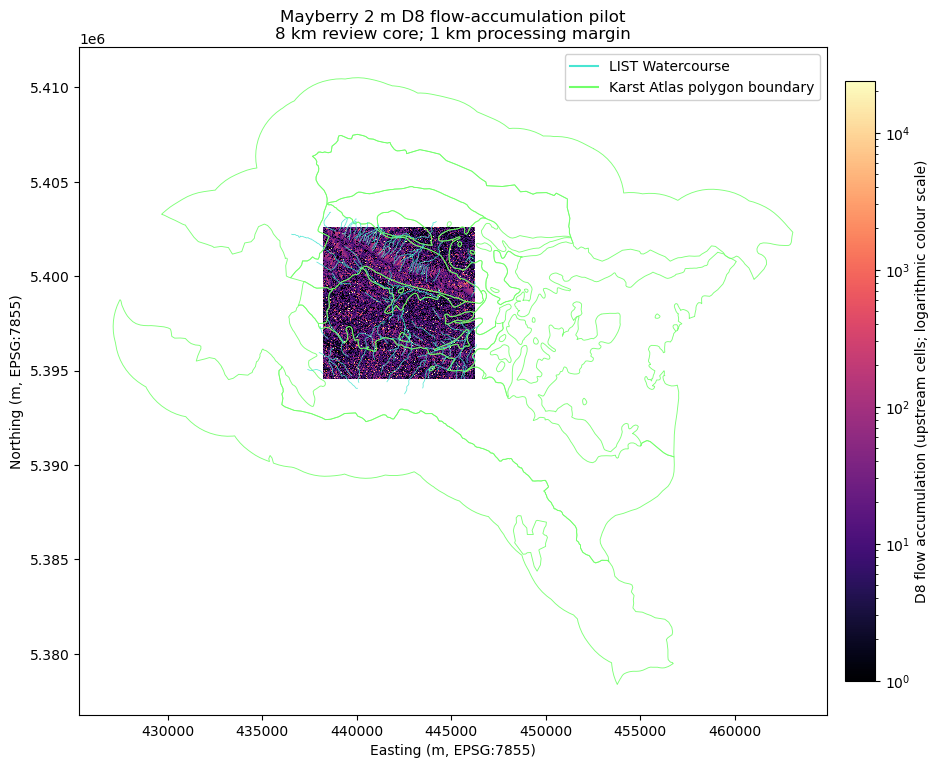

In [9]:
# Small-area test only: temporary rasters are deleted automatically when this cell finishes.
from pathlib import Path
import os
import tempfile
import time

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import whitebox
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from rasterio.windows import Window
from rasterio.transform import array_bounds

# This cell uses paths and spatial layers created by the earlier setup/data cells.
if "output_path" not in globals():
    raise RuntimeError("Run the notebook setup cell first so output_path is defined.")
if "watercourses_alt2" not in globals() or "karst_atlas" not in globals():
    raise RuntimeError("Run the Watercourse and Karst Atlas loading cells first for the map overlays.")

pilot_dem_path = Path(output_path) / "dem_mc_2m_EPSG7855.tif"
if not pilot_dem_path.is_file():
    raise FileNotFoundError(f"Prepared 2 m DEM not found: {pilot_dem_path}")

# The bounds are aligned to the 2 m grid of the prepared DEM (EPSG:7855).
pilot_bounds = (437192, 5393568, 447192, 5403568)  # outer 10 km processing window
review_bounds = (438192, 5394568, 446192, 5402568)  # inner 8 km map/review area
pilot_width = pilot_height = 5000
review_width = review_height = 4000
pilot_cell_count = pilot_width * pilot_height
print(f"Pilot window: {pilot_width:,} x {pilot_height:,} cells ({pilot_cell_count:,} total)")
print(f"One Float32 raster at this size is about {pilot_cell_count * 4 / 1024**2:.1f} MiB uncompressed.")

# Locate the standalone executable stored in the project, without downloading or installing it.
pilot_project_root = Path.cwd()
if pilot_project_root.name == "notebooks":
    pilot_project_root = pilot_project_root.parent
wbt_dir = pilot_project_root / "WhiteboxTools_win_amd64" / "WBT"
wbt_exe = wbt_dir / "whitebox_tools.exe"
if not wbt_exe.is_file():
    raise FileNotFoundError(f"WhiteboxTools executable not found: {wbt_exe}")

# The installed whitebox wrapper may auto-download on construction. WBT_PATH prevents that;
# set_whitebox_dir then points this wrapper at the executable already in the project.
os.environ["WBT_PATH"] = str(wbt_dir)
wbt = whitebox.WhiteboxTools()
wbt.set_whitebox_dir(str(wbt_dir))
wbt.verbose = False
print(f"WhiteboxTools version: {wbt.version()}")

with rasterio.open(pilot_dem_path) as dem_src:
    if dem_src.crs is None or dem_src.crs.to_epsg() != 7855:
        raise ValueError("The prepared 2 m DEM must be in EPSG:7855.")
    if dem_src.res != (2.0, 2.0):
        raise ValueError(f"Expected a 2 m DEM; found pixel size {dem_src.res}.")

    west, south, east, north = pilot_bounds
    col_off = int(round((west - dem_src.transform.c) / dem_src.transform.a))
    row_off = int(round((dem_src.transform.f - north) / abs(dem_src.transform.e)))
    tile_window = Window(col_off, row_off, pilot_width, pilot_height)
    tile_transform = dem_src.window_transform(tile_window)
    actual_bounds = array_bounds(pilot_height, pilot_width, tile_transform)  # west, south, east, north
    if not np.allclose(actual_bounds, pilot_bounds, atol=0.01):
        raise ValueError(f"Pilot bounds do not align with the source DEM grid: {actual_bounds}")
    if col_off < 0 or row_off < 0 or col_off + pilot_width > dem_src.width or row_off + pilot_height > dem_src.height:
        raise ValueError("Pilot window falls outside the prepared DEM.")

    pilot_dem = dem_src.read(1, window=tile_window, masked=True)
    if np.ma.getmaskarray(pilot_dem).any():
        raise ValueError("The selected pilot window contains NoData cells; choose a fully covered window.")
    pilot_profile = dem_src.profile.copy()
    pilot_profile.update(
        driver="GTiff", width=pilot_width, height=pilot_height, count=1,
        transform=tile_transform, compress="DEFLATE", tiled=True,
        blockxsize=256, blockysize=256,
    )
    source_nodata = dem_src.nodata

# Temporary inputs and outputs are cleaned up automatically; no project output is written.
with tempfile.TemporaryDirectory(prefix="wbt_mayberry_2m_pilot_") as temp_name:
    temp_dir = Path(temp_name)
    cropped_dem_path = temp_dir / "dem_mayberry_pilot_2m.tif"
    filled_dem_path = temp_dir / "dem_mayberry_pilot_filled.tif"
    flow_accum_path = temp_dir / "flow_accum_mayberry_pilot.tif"

    with rasterio.open(cropped_dem_path, "w", **pilot_profile) as tile_dst:
        tile_dst.write(np.asarray(pilot_dem.data, dtype="float32"), 1)

    wbt.set_working_dir(str(temp_dir))
    calculation_start = time.perf_counter()
    fill_start = time.perf_counter()
    wbt.fill_depressions(str(cropped_dem_path), str(filled_dem_path))
    fill_seconds = time.perf_counter() - fill_start
    if not filled_dem_path.is_file():
        raise RuntimeError("WhiteboxTools did not create the temporary filled DEM.")

    flow_start = time.perf_counter()
    wbt.d8_flow_accumulation(str(filled_dem_path), str(flow_accum_path), out_type="cells")
    flow_seconds = time.perf_counter() - flow_start
    total_seconds = time.perf_counter() - calculation_start
    if not flow_accum_path.is_file():
        raise RuntimeError("WhiteboxTools did not create the temporary flow-accumulation raster.")

    print(f"Depression filling time: {fill_seconds:.1f} seconds ({fill_seconds / 60:.2f} minutes)")
    print(f"D8 flow accumulation time: {flow_seconds:.1f} seconds ({flow_seconds / 60:.2f} minutes)")
    print(f"Total WhiteboxTools time: {total_seconds:.1f} seconds ({total_seconds / 60:.2f} minutes)")

    # Display only the inner 8 km core, leaving the 1 km processing margin outside the map.
    core_window = Window(500, 500, review_width, review_height)
    with rasterio.open(flow_accum_path) as flow_src:
        flow_core = flow_src.read(1, window=core_window, masked=True)
        core_transform = flow_src.window_transform(core_window)
        core_west, core_south, core_east, core_north = array_bounds(
            review_height, review_width, core_transform
        )
        flow_crs = flow_src.crs

    flow_core = np.ma.masked_less_equal(flow_core, 0)
    positive_flow = flow_core.compressed()
    if positive_flow.size == 0:
        raise ValueError("The pilot flow-accumulation raster has no positive valid cells in the review area.")
    display_max = max(float(np.percentile(positive_flow, 99.5)), 1.01)

    fig, ax = plt.subplots(figsize=(10, 8))
    image = ax.imshow(
        flow_core, origin="upper",
        extent=(core_west, core_east, core_south, core_north),
        cmap="magma", norm=LogNorm(vmin=1, vmax=display_max), interpolation="nearest",
    )
    colorbar = fig.colorbar(image, ax=ax, shrink=0.82, pad=0.02)
    colorbar.set_label("D8 flow accumulation (upstream cells; logarithmic colour scale)")

    watercourses_pilot = watercourses_alt2
    if watercourses_pilot.crs != flow_crs:
        watercourses_pilot = watercourses_pilot.to_crs(flow_crs)
    watercourses_pilot = watercourses_pilot.cx[core_west:core_east, core_south:core_north]
    if not watercourses_pilot.empty:
        watercourses_pilot.plot(ax=ax, color="#48e5d2", linewidth=0.55, alpha=0.9, zorder=3)

    karst_pilot = karst_atlas
    if karst_pilot.crs != flow_crs:
        karst_pilot = karst_pilot.to_crs(flow_crs)
    karst_pilot = karst_pilot.cx[core_west:core_east, core_south:core_north]
    if not karst_pilot.empty:
        karst_pilot.boundary.plot(ax=ax, color="#72ff6a", linewidth=0.65, alpha=0.9, zorder=2)

    legend_handles = [
        Line2D([0], [0], color="#48e5d2", linewidth=1.5, label="LIST Watercourse"),
        Line2D([0], [0], color="#72ff6a", linewidth=1.5, label="Karst Atlas polygon boundary"),
    ]
    ax.legend(handles=legend_handles, loc="upper right", framealpha=0.9)
    ax.set_title("Mayberry 2 m D8 flow-accumulation pilot\n8 km review core; 1 km processing margin")
    ax.set_xlabel("Easting (m, EPSG:7855)")
    ax.set_ylabel("Northing (m, EPSG:7855)")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()

## Cell-level connectivity to karst (2 m)

This additive step preserves the existing workflow and uses the same WhiteboxTools D8 method. It conditions the prepared 2 m DEM using the existing filled DEM, then delineates upstream cells that reach mapped karst polygons. Nonzero `KDISTCATCH` polygons are a subset of the targets for a separate distal-target evidence layer; the attribute itself is not a score. `KPROXCATCH` A?D is rasterised as binary presence. Mapped Watercourses are a comparison layer, not burned into the DEM.

The evidence raster has five classes: 0 no mapped evidence, 1 KPROXCATCH, 2 D8 route to karst, 3 D8 route to a KDISTCATCH target, and 4 KPROXCATCH plus a D8 route to karst. These are categorical labels, not weights.


## Five-class connectivity map (2 m)

The categorical map displays the evidence labels from the preceding cell.


## 2 m drainage network from mapped Watercourses and flow accumulation

This step checks that the mapped Watercourses and existing 2 m flow-accumulation raster share a usable CRS and extent, rasterises the Watercourses to the exact accumulation grid, and compares flow-accumulation values inside and outside mapped Watercourse cells. It selects a data-derived threshold by maximising pixel-level F1 agreement with the mapped lines; if several thresholds tie, it takes the lowest. This is a transparent calibration rule for review, not a universal channel threshold. The DEM and existing flow-accumulation workflow are not changed. The best-F1 threshold is an empirical candidate only; weak precision/recall means the comparison has not validated a reliable channel threshold.

The output is a binary raster: 1 = flow accumulation at or above the selected threshold; 0 = below it; 255 = NoData. Watercourse rasterisation uses `all_touched=True` so narrow mapped lines are represented on the 2 m grid.


In [ ]:
# Compare mapped Watercourses with the existing 2 m flow-accumulation raster;
# do not modify the DEM or recompute flow direction/accumulation in this cell.
from pathlib import Path
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
from rasterio.windows import Window

flow_accumulation_2m_path = output_path / "flow_accum_mc_2m_EPSG7855_alt2.tif"
watercourse_presence_2m_path = output_path / "watercourse_presence_mc_2m_EPSG7855_alt3.tif"
drainage_network_2m_path = output_path / "drainage_network_mc_2m_EPSG7855_alt3.tif"
threshold_report_path = output_path / "flowacc_watercourse_threshold_mc_2m_EPSG7855_alt3.csv"

if not flow_accumulation_2m_path.is_file():
    raise FileNotFoundError(f"Existing 2 m flow accumulation not found: {flow_accumulation_2m_path}")
if "watercourses_alt2" not in globals():
    raise RuntimeError("Run section 3 first to load the mapped Watercourse features.")
# Reuse section 3's merged vector features; only the rasterisation is repeated,
# because this analysis requires their mask on the separate 2 m grid.
watercourses_2m = watercourses_alt2.copy()
if watercourses_2m.empty:
    raise ValueError("No mapped Watercourse features are available")
if watercourses_2m.crs is None:
    raise ValueError("Mapped Watercourse features have no CRS")

with rasterio.open(flow_accumulation_2m_path) as flow_src:
    if flow_src.crs is None or flow_src.res != (2.0, 2.0):
        raise ValueError(f"Expected a georeferenced 2 m flow-accumulation raster; found {flow_src.crs}, {flow_src.res}")
    flow_crs_2m = flow_src.crs
    flow_transform_2m = flow_src.transform
    flow_shape_2m = (flow_src.height, flow_src.width)
    flow_bounds_2m = flow_src.bounds
    flow_profile_2m = flow_src.profile.copy()
    flow_nodata_2m = flow_src.nodata

watercourse_source_crs_2m = watercourses_2m.crs
if watercourses_2m.crs != flow_crs_2m:
    watercourses_2m = watercourses_2m.to_crs(flow_crs_2m)
watercourse_bounds_2m = watercourses_2m.total_bounds
left, bottom, right, top = flow_bounds_2m
if (watercourse_bounds_2m[2] < left or watercourse_bounds_2m[0] > right or
        watercourse_bounds_2m[3] < bottom or watercourse_bounds_2m[1] > top):
    raise ValueError("Watercourse layer extent does not overlap the flow-accumulation raster")
print(f"Reused mapped Watercourse features: {len(watercourses_2m):,}")
print(f"CRS: Watercourses {watercourse_source_crs_2m} -> {flow_crs_2m}; raster {flow_crs_2m}")
print(f"Watercourse bounds in raster CRS: {tuple(round(v, 2) for v in watercourse_bounds_2m)}")
print(f"Flow grid bounds: {tuple(round(v, 2) for v in (left, bottom, right, top))}")
print(f"Flow grid: {flow_shape_2m[0]:,} x {flow_shape_2m[1]:,}; resolution {flow_profile_2m['transform'].a:g} m; transform {flow_transform_2m}")

# Burn the lines onto the exact flow-accumulation grid; this is evidence for calibration,
# not an elevation burn and not a change to the hydrology inputs.
watercourse_presence_2m = rasterize(
    ((geom, 1) for geom in watercourses_2m.geometry),
    out_shape=flow_shape_2m, transform=flow_transform_2m,
    fill=0, dtype="uint8", all_touched=True,
)
watercourse_profile_2m = flow_profile_2m.copy()
watercourse_profile_2m.update(driver="GTiff", count=1, dtype="uint8", nodata=255,
                               compress="DEFLATE", tiled=True, blockxsize=256, blockysize=256, BIGTIFF="IF_SAFER")
# Preserve the source accumulation NoData footprint in the Watercourse mask.
with rasterio.open(flow_accumulation_2m_path) as flow_src:
    for row in range(0, flow_shape_2m[0], 128):
        h = min(128, flow_shape_2m[0] - row)
        values = flow_src.read(1, window=Window(0, row, flow_shape_2m[1], h), masked=True)
        invalid = np.ma.getmaskarray(values) | ~np.isfinite(values.data)
        watercourse_presence_2m[row:row+h][invalid] = 255
with rasterio.open(watercourse_presence_2m_path, "w", **watercourse_profile_2m) as dst:
    # Write by row blocks so the large 2 m array is not duplicated in memory.
    for row in range(0, flow_shape_2m[0], 256):
        h = min(256, flow_shape_2m[0] - row)
        dst.write(watercourse_presence_2m[row:row+h], 1, window=Window(0, row, flow_shape_2m[1], h))

# Accumulate log-spaced histograms of flow values on mapped-line and other valid cells.
# Their cumulative counts give a transparent precision/recall/F1 comparison for each threshold.
max_possible_cells = flow_shape_2m[0] * flow_shape_2m[1]
hist_edges = np.unique(np.concatenate(([0.5], np.geomspace(1.0, max_possible_cells + 1.0, 2049))))
watercourse_hist = np.zeros(len(hist_edges) - 1, dtype=np.int64)
other_hist = np.zeros_like(watercourse_hist)
valid_count = watercourse_cell_count = 0
with rasterio.open(flow_accumulation_2m_path) as flow_src:
    for row in range(0, flow_shape_2m[0], 128):
        h = min(128, flow_shape_2m[0] - row)
        win = Window(0, row, flow_shape_2m[1], h)
        values = flow_src.read(1, window=win, masked=True)
        valid = ~np.ma.getmaskarray(values) & np.isfinite(values.data)
        wc = watercourse_presence_2m[row:row+h] == 1
        vals = values.data[valid]
        labels = wc[valid]
        valid_count += int(valid.sum())
        watercourse_cell_count += int(labels.sum())
        watercourse_hist += np.histogram(vals[labels], bins=hist_edges)[0]
        other_hist += np.histogram(vals[~labels], bins=hist_edges)[0]

if watercourse_cell_count == 0:
    raise ValueError("No mapped Watercourse cells overlap valid flow-accumulation cells")
thresholds = np.ceil(hist_edges[:-1]).astype("int64")
tp = np.cumsum(watercourse_hist[::-1])[::-1]
fp = np.cumsum(other_hist[::-1])[::-1]
fn = watercourse_cell_count - tp
precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype="float64"), where=(tp + fp) > 0)
recall = np.divide(tp, tp + fn, out=np.zeros_like(tp, dtype="float64"), where=(tp + fn) > 0)
f1 = np.divide(2 * precision * recall, precision + recall,
               out=np.zeros_like(precision), where=(precision + recall) > 0)
# Choose maximum F1; np.argmax selects the lowest threshold when scores tie.
best_i = int(np.argmax(f1))
selected_flow_threshold = int(thresholds[best_i])

# Recount exact confusion values at the chosen integer threshold, then write aligned output.
exact_tp = exact_fp = 0
with rasterio.open(flow_accumulation_2m_path) as flow_src:
    for row in range(0, flow_shape_2m[0], 128):
        h = min(128, flow_shape_2m[0] - row)
        win = Window(0, row, flow_shape_2m[1], h)
        values = flow_src.read(1, window=win, masked=True)
        valid = ~np.ma.getmaskarray(values) & np.isfinite(values.data)
        wc = watercourse_presence_2m[row:row+h] == 1
        predicted = (values.data >= selected_flow_threshold) & valid
        exact_tp += int((predicted & wc).sum())
        exact_fp += int((predicted & ~wc & valid).sum())
exact_fn = watercourse_cell_count - exact_tp
exact_precision = exact_tp / (exact_tp + exact_fp) if exact_tp + exact_fp else 0.0
exact_recall = exact_tp / watercourse_cell_count
exact_f1 = (2 * exact_precision * exact_recall / (exact_precision + exact_recall)
            if exact_precision + exact_recall else 0.0)

network_profile_2m = flow_profile_2m.copy()
network_profile_2m.update(driver="GTiff", count=1, dtype="uint8", nodata=255,
                           compress="DEFLATE", tiled=True, blockxsize=256, blockysize=256, BIGTIFF="IF_SAFER")
with rasterio.open(flow_accumulation_2m_path) as flow_src, rasterio.open(drainage_network_2m_path, "w", **network_profile_2m) as dst:
    for row in range(0, flow_shape_2m[0], 128):
        h = min(128, flow_shape_2m[0] - row)
        win = Window(0, row, flow_shape_2m[1], h)
        values = flow_src.read(1, window=win, masked=True)
        valid = ~np.ma.getmaskarray(values) & np.isfinite(values.data)
        binary = np.where(valid, values.data >= selected_flow_threshold, 255).astype("uint8")
        dst.write(binary, 1, window=win)

# Save the tested threshold curve so the empirical choice can be reviewed or revised.
threshold_report = pd.DataFrame({
    "flow_accumulation_threshold_cells": thresholds,
    "mapped_watercourse_true_positive_cells": tp,
    "non_watercourse_predicted_channel_cells": fp,
    "precision": precision, "recall": recall, "f1": f1,
})
threshold_report = threshold_report.loc[threshold_report["flow_accumulation_threshold_cells"].diff().fillna(1).ne(0)]
threshold_report.to_csv(threshold_report_path, index=False)

# Confirm both output rasters exactly retain the source grid.
for check_path in (watercourse_presence_2m_path, drainage_network_2m_path):
    with rasterio.open(check_path) as check:
        if (check.shape, check.crs, check.transform, check.res) != (flow_shape_2m, flow_crs_2m, flow_transform_2m, (2.0, 2.0)):
            raise ValueError(f"Output raster does not match the flow grid: {check_path}")
print(f"Valid flow cells: {valid_count:,}; mapped Watercourse cells: {watercourse_cell_count:,}")
print(f"Selected minimum threshold among best-F1 ties: {selected_flow_threshold:,} upstream cells")
print(f"Exact agreement: precision={exact_precision:.3f}; recall={exact_recall:.3f}; F1={exact_f1:.3f}")
print(f"Watercourse mask: {watercourse_presence_2m_path}")
print(f"Binary drainage network: {drainage_network_2m_path}")
print(f"Threshold comparison table: {threshold_report_path}")


## Review the threshold comparison and derived drainage raster

The first panel shows the mapped Watercourse and predicted-channel agreement across tested thresholds. A second figure overlays mapped Watercourse cells on the DEM-derived drainage raster across the full study area. It downsamples only the display for plotting; the saved rasters retain the full 2 m grid.


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from rasterio.windows import Window

# Compare flow-accumulation distributions, then show agreement across thresholds.
fig, (ax_dist, ax_score) = plt.subplots(1, 2, figsize=(13, 4.5))
bin_centres = np.sqrt(hist_edges[:-1] * hist_edges[1:])
wc_total = max(int(watercourse_hist.sum()), 1)
other_total = max(int(other_hist.sum()), 1)
ax_dist.plot(bin_centres, watercourse_hist / wc_total, label="Mapped Watercourse cells")
ax_dist.plot(bin_centres, other_hist / other_total, label="Other valid cells")
ax_dist.set_xscale("log")
ax_dist.set_yscale("log")
ax_dist.set_xlabel("Flow accumulation (upstream cells; log scale)")
ax_dist.set_ylabel("Share of cells per log-spaced bin")
ax_dist.set_title("Accumulation value distributions")
ax_dist.grid(True, alpha=0.25)
ax_dist.legend(fontsize=8)

curve = threshold_report.loc[threshold_report["flow_accumulation_threshold_cells"] > 0]
ax_score.plot(curve["flow_accumulation_threshold_cells"], curve["precision"], label="Precision")
ax_score.plot(curve["flow_accumulation_threshold_cells"], curve["recall"], label="Recall")
ax_score.plot(curve["flow_accumulation_threshold_cells"], curve["f1"], label="F1")
ax_score.axvline(selected_flow_threshold, color="black", linestyle="--", label=f"Selected: {selected_flow_threshold:,} cells")
ax_score.set_xscale("log")
ax_score.set_xlabel("Flow accumulation threshold (upstream cells; log scale)")
ax_score.set_ylabel("Agreement with mapped Watercourse cells")
ax_score.set_ylim(0, 1)
ax_score.grid(True, alpha=0.25)
ax_score.legend(fontsize=8)
ax_score.set_title("Threshold agreement")
fig.suptitle("Existing 2 m flow accumulation compared with mapped Watercourses")
plt.tight_layout()
plt.show()

# Overlay mapped Watercourse cells and DEM-derived drainage over the full area.
# Downsampling is display-only; saved rasters remain on the exact 2 m grid.
from rasterio.enums import Resampling
from matplotlib.patches import Patch

max_display_dimension = 2500
with rasterio.open(drainage_network_2m_path) as src:
    scale = min(1.0, max_display_dimension / max(src.height, src.width))
    display_shape = (max(1, round(src.height * scale)), max(1, round(src.width * scale)))
    drainage_display = src.read(1, out_shape=display_shape, masked=True, resampling=Resampling.nearest)
    map_extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)
    map_crs = src.crs
with rasterio.open(watercourse_presence_2m_path) as src:
    if (src.shape, src.crs, src.transform) != (flow_shape_2m, flow_crs_2m, flow_transform_2m):
        raise ValueError("Watercourse mask does not align with the drainage raster")
    watercourse_display = src.read(1, out_shape=display_shape, masked=True, resampling=Resampling.nearest)

# Codes distinguish DEM drainage, mapped Watercourses, and cells where both overlap.
no_data = np.ma.getmaskarray(drainage_display) | np.ma.getmaskarray(watercourse_display)
drainage_values = np.asarray(drainage_display.data)
watercourse_values = np.asarray(watercourse_display.data)
overlay = np.zeros(display_shape, dtype="uint8")
overlay[(drainage_values == 1) & (watercourse_values != 1)] = 1
overlay[(watercourse_values == 1) & (drainage_values != 1)] = 2
overlay[(drainage_values == 1) & (watercourse_values == 1)] = 3
overlay_display = np.ma.array(overlay, mask=no_data)

overlay_colors = ["#eeeeee", "#d73027", "#2878b5", "#7b3294"]
fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(
    overlay_display, extent=map_extent, origin="upper",
    cmap=ListedColormap(overlay_colors), vmin=-0.5, vmax=3.5,
    interpolation="nearest",
)
ax.legend(handles=[
    Patch(facecolor=overlay_colors[0], label="Neither layer"),
    Patch(facecolor=overlay_colors[1], label="DEM-derived drainage only"),
    Patch(facecolor=overlay_colors[2], label="Mapped Watercourse only"),
    Patch(facecolor=overlay_colors[3], label="Overlap"),
], title="2 m drainage evidence", loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
ax.set_title(f"DEM-derived drainage and mapped Watercourses\nFlow-accumulation threshold: {selected_flow_threshold:,} upstream cells")
ax.set_xlabel("Easting (m)")
ax.set_ylabel(f"Northing (m, {map_crs})")
ax.set_aspect("equal", adjustable="box")
fig.subplots_adjust(right=0.75)
plt.show()


## Prepare binary Kproxcatch and Kdistcatch masks

This cell validates the prepared 2 m DEM and existing flow-accumulation grids, loads the existing Karst Atlas GeoPackage, and rasterises the source masks on the exact 2 m grid. `KPROXCATCH` A?D are all presence (1); `KDISTCATCH` 1 or 2 are both presence (1). The 73 features with positive `karst_intensity` are used as karst destination polygons. No Atlas values are used as weights.


In [ ]:
# Prepare binary Kproxcatch and Kdistcatch source masks on the existing 2 m grid;
# the DEM and flow-accumulation inputs are read only.
from pathlib import Path
import os
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
from rasterio.windows import Window
from rasterio.windows import transform as window_transform

filled_dem_connectivity_path = output_path / "dem_mc_2m_filled_EPSG7855_alt2.tif"
flow_accumulation_2m_path = output_path / "flow_accum_mc_2m_EPSG7855_alt2.tif"
d8_pointer_connectivity_path = output_path / "d8_pointer_mc_2m_EPSG7855_connectivity.tif"
kprox_presence_connectivity_path = output_path / "kproxcatch_presence_mc_2m_EPSG7855_connectivity.tif"
kdist_presence_connectivity_path = output_path / "kdistcatch_presence_mc_2m_EPSG7855_connectivity.tif"
karst_upstream_counts_path = output_path / "karst_upstream_connectivity_counts_core_mc_2m_EPSG7855.csv"

if not filled_dem_connectivity_path.is_file() or not flow_accumulation_2m_path.is_file():
    raise FileNotFoundError("Run/use the existing 2 m preparation and D8 accumulation outputs first")
karst_atlas_connectivity = gpd.read_file(karst_atlas_path)
needed = {"KPROXCATCH", "KDISTCATCH", "karst_intensity", "OBJECTID", "KNAME"}
if not needed.issubset(karst_atlas_connectivity.columns):
    raise KeyError(f"Karst layer is missing required fields: {sorted(needed - set(karst_atlas_connectivity.columns))}")
if karst_atlas_connectivity.crs is None:
    raise ValueError("Karst polygons have no CRS")

with rasterio.open(filled_dem_connectivity_path) as dem_src, rasterio.open(flow_accumulation_2m_path) as flow_src:
    grid = (dem_src.shape, dem_src.crs, dem_src.transform, dem_src.res)
    if (flow_src.shape, flow_src.crs, flow_src.transform, flow_src.res) != grid:
        raise ValueError("Filled DEM and flow accumulation do not share the exact grid")
    if dem_src.crs is None or dem_src.res != (2.0, 2.0):
        raise ValueError(f"Expected the prepared 2 m grid; found {dem_src.crs}, {dem_src.res}")
    dem_shape, dem_crs, dem_transform = dem_src.shape, dem_src.crs, dem_src.transform
    dem_profile = dem_src.profile.copy()
    flow_profile = flow_src.profile.copy()

karst_atlas_connectivity = karst_atlas_connectivity.loc[
    karst_atlas_connectivity.geometry.notna() & ~karst_atlas_connectivity.geometry.is_empty
].copy()
if karst_atlas_connectivity.crs != dem_crs:
    karst_atlas_connectivity = karst_atlas_connectivity.to_crs(dem_crs)
# Match the core names selected in 00_bounding_boxes; other buffer polygons remain source evidence only.
normalized_kname = karst_atlas_connectivity["KNAME"].astype("string").str.replace(r"\s+", " ", regex=True).str.strip()
core_karst_names = {"Mole Creek", "Meander - Western Creek", "Mole Creek (Chudleigh Hill)"}
core_name_mask = normalized_kname.isin(core_karst_names)
karst_core_connectivity = karst_atlas_connectivity.loc[core_name_mask].copy()
if karst_core_connectivity.empty:
    raise ValueError(f"No core Mole Creek polygons found using names: {sorted(core_karst_names)}")
mole_creek_core_connectivity = karst_core_connectivity.geometry.union_all()
positive_intensity = pd.to_numeric(karst_atlas_connectivity["karst_intensity"], errors="coerce") > 0
inside_core_geometry = karst_atlas_connectivity.geometry.intersects(mole_creek_core_connectivity)
karst_targets_connectivity = karst_atlas_connectivity.loc[
    core_name_mask & inside_core_geometry & positive_intensity
].copy().reset_index(drop=True)
karst_targets_connectivity["KNAME"] = (
    karst_targets_connectivity["KNAME"].astype("string").str.replace(r"\s+", " ", regex=True).str.strip()
)
if karst_targets_connectivity.empty:
    raise ValueError("No karst target polygons have positive mapped karst intensity")

# A/B/C/D all become 1; Kdistcatch values 1 and 2 both become 1.
kprox_values = karst_atlas_connectivity["KPROXCATCH"].astype("string").str.strip().str.upper()
kprox_features = karst_atlas_connectivity.loc[kprox_values.isin(["A", "B", "C", "D"])]
kdist_values = pd.to_numeric(karst_atlas_connectivity["KDISTCATCH"], errors="coerce")
kdist_features = karst_atlas_connectivity.loc[kdist_values.notna() & kdist_values.ne(0)]
kprox_source = rasterize(
    ((geom, 1) for geom in kprox_features.geometry), out_shape=dem_shape,
    transform=dem_transform, fill=0, dtype="uint8",
)
kdist_source = rasterize(
    ((geom, 1) for geom in kdist_features.geometry), out_shape=dem_shape,
    transform=dem_transform, fill=0, dtype="uint8",
)
source_overlap = (kprox_source & kdist_source).astype("uint8")

# Save reusable binary source masks on the exact 2 m grid for review and plotting.
mask_profile = dem_profile.copy()
mask_profile.update(driver="GTiff", count=1, dtype="uint8", nodata=255,
                    compress="DEFLATE", tiled=True, blockxsize=256, blockysize=256, BIGTIFF="IF_SAFER")
with rasterio.open(filled_dem_connectivity_path) as dem_src:
    dem_valid = dem_src.dataset_mask() > 0
for name, source_mask, target_path in (
    ("Kproxcatch", kprox_source, kprox_presence_connectivity_path),
    ("Kdistcatch", kdist_source, kdist_presence_connectivity_path),
):
    source_mask[~dem_valid] = 255
    with rasterio.open(target_path, "w", **mask_profile) as dst:
        for row in range(0, dem_shape[0], 256):
            h = min(256, dem_shape[0] - row)
            dst.write(source_mask[row:row+h], 1, window=Window(0, row, dem_shape[1], h))
# Restore source masks to 0/1 in the valid footprint for routing.
kprox_source[~dem_valid] = 0
kdist_source[~dem_valid] = 0
source_overlap = (kprox_source & kdist_source).astype("uint8")
del dem_valid
print(f"Core karst destination polygons: {len(karst_targets_connectivity):,}")
print(f"Core polygon names: {sorted(karst_targets_connectivity['KNAME'].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip().unique())}")
print("Buffer-only Kproxcatch/Kdistcatch cells remain in the source masks and can contribute to core targets.")
print(f"KPROXCATCH A-D binary source cells: {int(kprox_source.sum()):,}")
print(f"KDISTCATCH 1/2 binary source cells: {int(kdist_source.sum()):,}")
print(f"2 m Kprox mask: {kprox_presence_connectivity_path}")
print(f"2 m Kdist mask: {kdist_presence_connectivity_path}")



## Binary Kproxcatch map with karst polygons

The map shows KPROXCATCH presence/absence (all A?D values are 1) on the existing coarse flow grid, with the mapped karst polygons outlined. The detailed binary source mask remains on the exact 2 m DEM grid for routing.


C:\Users\innoc\AppData\Local\Temp\ipykernel_27228\3188670442.py:33: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  coarse_kprox = src.read(1)


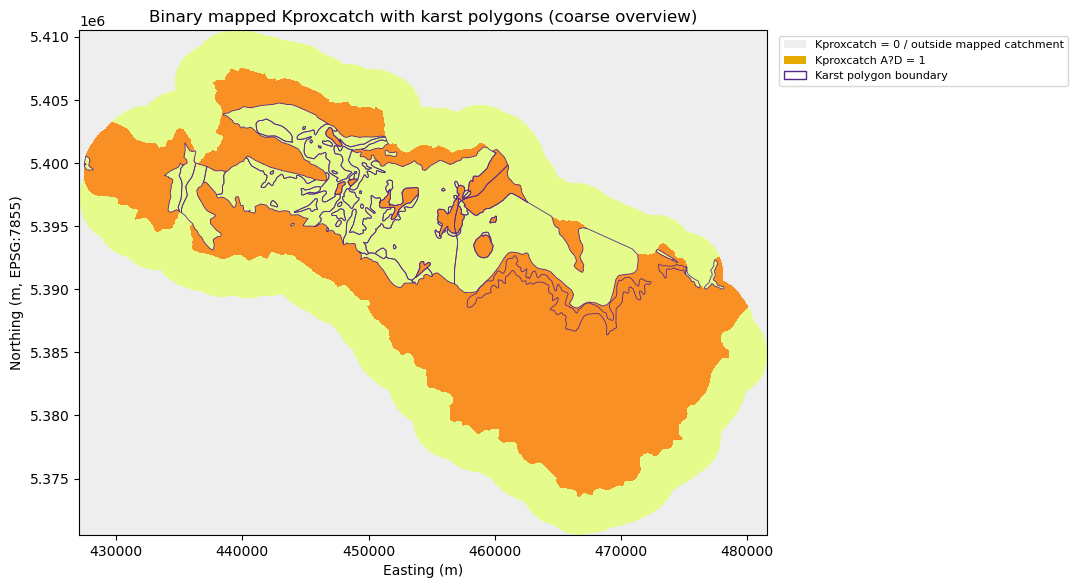

In [17]:
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.patches import Patch
import rasterio
import numpy as np
from pathlib import Path
import os
import pandas as pd

# Resolve the output folder independently so this overview works after a kernel restart.
working_dir = Path.cwd()
project_root = working_dir.parent if working_dir.name == "notebooks" else working_dir
data_dir_value = os.environ.get("AT3_DATA_DIR")
if not data_dir_value:
    env_file = project_root / ".env"
    if env_file.exists():
        for line in env_file.read_text(encoding="utf-8-sig").splitlines():
            entry = line.strip()
            if entry.startswith("AT3_DATA_DIR="):
                data_dir_value = entry.split("=", 1)[1].strip().strip("\"").strip("'")
                break
data_path = Path(data_dir_value).expanduser() if data_dir_value else project_root / "data"
if not data_path.is_absolute():
    data_path = (project_root / data_path).resolve()
output_path = data_path / "Output_data"
karst_atlas_path = output_path / "karst_mc_susceptibility_EPSG7855.gpkg"
# Display the existing coarse-grid Kprox raster for a readable regional overview.
# The separate connectivity mask remains on the exact 2 m grid for D8 routing.
coarse_kprox_path = output_path / "kproxcatch_presence_mc_EPSG7855_alt2.tif"
if not coarse_kprox_path.is_file():
    raise FileNotFoundError(f"Coarse Kproxcatch raster not found: {coarse_kprox_path}")
with rasterio.open(coarse_kprox_path) as src:
    coarse_kprox = src.read(1)
    map_crs = src.crs
    map_bounds = src.bounds
coarse_nodata = src.nodata
coarse_display = np.ma.masked_equal(coarse_kprox, coarse_nodata) if coarse_nodata is not None else np.ma.masked_invalid(coarse_kprox)
karst_plot = gpd.read_file(karst_atlas_path)
if karst_plot.crs is None or "KNAME" not in karst_plot.columns:
    raise ValueError("Karst Atlas layer must have a CRS and KNAME field")
core_names_for_plot = {"Mole Creek", "Meander - Western Creek", "Mole Creek (Chudleigh Hill)"}
normalized_plot_names = karst_plot["KNAME"].astype("string").str.replace(r"\s+", " ", regex=True).str.strip()
karst_plot = karst_plot.loc[
    karst_plot.geometry.notna() & ~karst_plot.geometry.is_empty & normalized_plot_names.isin(core_names_for_plot)
].copy()
# Simplify display geometries only; source vectors and raster masks are unchanged.
karst_plot.geometry = karst_plot.geometry.simplify(25, preserve_topology=True)
if karst_plot.crs != map_crs:
    karst_plot = karst_plot.to_crs(map_crs)

left, bottom, right, top = map_bounds
fig, ax = plt.subplots(figsize=(11, 8))
ax.set_facecolor("#eeeeee")  # 0 = no mapped Kproxcatch polygon
ax.imshow(coarse_display, extent=(left, right, bottom, top), origin="upper", cmap="Wistia", vmin=0, vmax=1, interpolation="nearest", alpha=0.85, zorder=1)
karst_plot.boundary.plot(ax=ax, color="#542788", linewidth=0.65, alpha=0.9, zorder=2)
ax.set_xlim(left, right)
ax.set_ylim(bottom, top)
ax.legend(handles=[Patch(facecolor="#eeeeee", label="Kproxcatch = 0 / outside mapped catchment"),
                   Patch(facecolor="#e6ab02", label="Kproxcatch A?D = 1"),
                   Patch(facecolor="none", edgecolor="#542788", label="Karst polygon boundary")],
          loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
ax.set_title("Binary mapped Kproxcatch with karst polygons (coarse overview)")
ax.set_xlabel("Easting (m)")
ax.set_ylabel(f"Northing (m, {map_crs})")
ax.set_aspect("equal", adjustable="box")
fig.subplots_adjust(right=0.75)
plt.show()


## D8 routing counts for each karst polygon

The next cell reuses the saved D8 pointer from the existing filled DEM and counts source cells whose D8 path reaches each core target. Target rows are limited to Mole Creek, Meander - Western Creek, and Mole Creek (Chudleigh Hill), matching `00_bounding_boxes`. Kproxcatch and Kdistcatch source cells remain across the full buffered Atlas layer, so buffer cells can contribute to core targets. Each source cell is counted at most once per target, and may count for multiple core targets. The table reports unique upstream cell counts and area. This is a surface-flow estimate; it cannot confirm underground continuation.

The routing arrays are large (about 13 GiB before runtime overhead for this grid). The saved D8 pointer is reused, but sufficient RAM is still required for the unique-target reachability arrays.


In [ ]:
# Reuse the saved 2 m D8 pointer and count unique source cells reaching each core karst target.
from pathlib import Path
import os
import whitebox
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
from numba import njit

project_root_connectivity = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
configured_wbt_path = os.environ.get("WBT_PATH")
wbt_dir_connectivity = Path(configured_wbt_path) if configured_wbt_path else project_root_connectivity / "WhiteboxTools_win_amd64" / "WBT"
if wbt_dir_connectivity.is_file():
    wbt_dir_connectivity = wbt_dir_connectivity.parent
if not (wbt_dir_connectivity / "whitebox_tools.exe").is_file():
    raise FileNotFoundError(f"WhiteboxTools executable not found in {wbt_dir_connectivity}")
if not d8_pointer_connectivity_path.is_file():
    os.environ["WBT_PATH"] = str(wbt_dir_connectivity)
    wbt_connectivity = whitebox.WhiteboxTools()
    wbt_connectivity.set_whitebox_dir(str(wbt_dir_connectivity))
    wbt_connectivity.verbose = True
    wbt_connectivity.set_working_dir(str(output_path))
    wbt_connectivity.d8_pointer(
        str(filled_dem_connectivity_path), str(d8_pointer_connectivity_path), esri_pntr=False
    )

target_names = karst_targets_connectivity["KNAME"].astype("string").str.replace(r"\s+", " ", regex=True).str.strip()
unexpected_targets = set(target_names.astype(str)) - core_karst_names
if unexpected_targets:
    raise ValueError(f"Non-core polygons found in target set: {sorted(unexpected_targets)}")
target_count = len(karst_targets_connectivity)
if target_count == 0:
    raise ValueError("No positive-intensity core karst targets are available")

with rasterio.open(d8_pointer_connectivity_path) as pointer_src:
    if (pointer_src.shape, pointer_src.crs, pointer_src.transform, pointer_src.res) != grid:
        raise ValueError("Saved D8 pointer raster does not match the exact 2 m DEM grid")
    pointer_nodata = pointer_src.nodata
    if pointer_nodata is None:
        raise ValueError("D8 pointer raster must define NoData outside valid DEM cells")
    pointer = pointer_src.read(1).astype("int16", copy=False)

# Encode each core target as a bit. Two planes cover up to 128 polygons and let one
# reverse traversal count each source cell once per target, even if a path re-enters it.
target_reach_low = np.zeros(dem_shape, dtype=np.uint64)
target_reach_high = np.zeros(dem_shape, dtype=np.uint64)
target_cell_counts = np.zeros(target_count, dtype=np.uint64)
for target_index, (_, feature) in enumerate(karst_targets_connectivity.iterrows()):
    geom = feature.geometry
    minx, miny, maxx, maxy = geom.bounds
    col0 = max(0, int(np.floor((minx - dem_transform.c) / dem_transform.a)))
    col1 = min(dem_shape[1], int(np.ceil((maxx - dem_transform.c) / dem_transform.a)) + 1)
    row0 = max(0, int(np.floor((dem_transform.f - maxy) / abs(dem_transform.e))))
    row1 = min(dem_shape[0], int(np.ceil((dem_transform.f - miny) / abs(dem_transform.e))) + 1)
    local_transform = dem_transform * rasterio.Affine.translation(col0, row0)
    inside = rasterize(
        [(geom, 1)], out_shape=(row1 - row0, col1 - col0),
        transform=local_transform, fill=0, dtype="uint8"
    ).astype(bool)
    inside &= pointer[row0:row1, col0:col1] != pointer_nodata
    target_cell_counts[target_index] = int(inside.sum())
    if target_index < 64:
        target_reach_low[row0:row1, col0:col1][inside] |= np.uint64(1) << np.uint64(target_index)
    else:
        target_reach_high[row0:row1, col0:col1][inside] |= np.uint64(1) << np.uint64(target_index - 64)

bit_counts_lut = np.zeros(256, dtype=np.uint8)
bit_indices_lut = np.zeros((256, 8), dtype=np.uint8)
for value in range(256):
    indices = [bit for bit in range(8) if value & (1 << bit)]
    bit_counts_lut[value] = len(indices)
    if indices:
        bit_indices_lut[value, :len(indices)] = indices

@njit(inline="always")
def _d8_receiver(pointer_array, row, col, nodata_value):
    height, width = pointer_array.shape
    code = int(pointer_array[row, col])
    dr = 0
    dc = 0
    if code == 1: dc = 1
    elif code == 2: dr = 1; dc = 1
    elif code == 4: dr = 1
    elif code == 8: dr = 1; dc = -1
    elif code == 16: dc = -1
    elif code == 32: dr = -1; dc = -1
    elif code == 64: dr = -1
    elif code == 128: dr = -1; dc = 1
    else: return -1
    nr, nc = row + dr, col + dc
    if nr < 0 or nr >= height or nc < 0 or nc >= width:
        return -1
    if pointer_array[nr, nc] == nodata_value:
        return -1
    return nr * width + nc

@njit(inline="always")
def _add_reachable_bits(mask, base, bit_counts, bit_indices,
                        total_counts, prox_counts, dist_counts, overlap_counts,
                        is_prox, is_dist):
    for byte_index in range(8):
        value = int((mask >> np.uint64(byte_index * 8)) & np.uint64(255))
        for j in range(int(bit_counts[value])):
            target_index = base + int(bit_indices[value, j])
            total_counts[target_index] += 1
            if is_prox:
                prox_counts[target_index] += 1
            if is_dist:
                dist_counts[target_index] += 1
            if is_prox and is_dist:
                overlap_counts[target_index] += 1

@njit
def _count_unique_upstream_by_target(pointer_array, prox_array, dist_array,
                                     reach_low, reach_high, nodata_value,
                                     bit_counts, bit_indices, n_targets):
    height, width = pointer_array.shape
    indegree = np.zeros((height, width), dtype=np.uint8)
    valid_count = 0
    for row in range(height):
        for col in range(width):
            if pointer_array[row, col] == nodata_value:
                continue
            valid_count += 1
            receiver = _d8_receiver(pointer_array, row, col, nodata_value)
            if receiver >= 0:
                rr = receiver // width
                indegree[rr, receiver - rr * width] += 1

    order = np.empty(valid_count, dtype=np.int32)
    head = 0
    tail = 0
    for row in range(height):
        for col in range(width):
            if pointer_array[row, col] != nodata_value and indegree[row, col] == 0:
                order[tail] = row * width + col
                tail += 1
    while head < tail:
        idx = order[head]
        head += 1
        row = idx // width
        receiver = _d8_receiver(pointer_array, row, idx - row * width, nodata_value)
        if receiver >= 0:
            rr = receiver // width
            rc = receiver - rr * width
            indegree[rr, rc] -= 1
            if indegree[rr, rc] == 0:
                order[tail] = receiver
                tail += 1

    processed = tail
    unresolved = valid_count - processed
    total = np.zeros(n_targets, dtype=np.uint64)
    prox = np.zeros(n_targets, dtype=np.uint64)
    dist = np.zeros(n_targets, dtype=np.uint64)
    overlap = np.zeros(n_targets, dtype=np.uint64)

    # Treat each closed pointer cycle as a closed routing unit. Its cells can reach
    # targets inside that same cycle; no flow is allowed to continue beyond the loop.
    if unresolved:
        for row in range(height):
            for col in range(width):
                if pointer_array[row, col] == nodata_value or indegree[row, col] == 0:
                    continue
                start = row * width + col
                current = start
                smallest = start
                while True:
                    cr = current // width
                    cc = current - cr * width
                    receiver = _d8_receiver(pointer_array, cr, cc, nodata_value)
                    if receiver < 0:
                        break
                    if receiver < smallest:
                        smallest = receiver
                    current = receiver
                    if current == start:
                        break
                if smallest != start:
                    continue

                cycle_low = np.uint64(0)
                cycle_high = np.uint64(0)
                current = start
                while True:
                    cr = current // width
                    cc = current - cr * width
                    cycle_low |= reach_low[cr, cc]
                    cycle_high |= reach_high[cr, cc]
                    receiver = _d8_receiver(pointer_array, cr, cc, nodata_value)
                    if receiver < 0 or receiver == start:
                        break
                    current = receiver

                current = start
                while True:
                    cr = current // width
                    cc = current - cr * width
                    own_low, own_high = reach_low[cr, cc], reach_high[cr, cc]
                    is_prox, is_dist = prox_array[cr, cc] != 0, dist_array[cr, cc] != 0
                    _add_reachable_bits(cycle_low & ~own_low, 0, bit_counts, bit_indices, total, prox, dist, overlap, is_prox, is_dist)
                    _add_reachable_bits(cycle_high & ~own_high, 64, bit_counts, bit_indices, total, prox, dist, overlap, is_prox, is_dist)
                    reach_low[cr, cc], reach_high[cr, cc] = cycle_low, cycle_high
                    receiver = _d8_receiver(pointer_array, cr, cc, nodata_value)
                    if receiver < 0 or receiver == start:
                        break
                    current = receiver

    # Every downstream reachability set is ready before processing its upstream cells.
    for pos in range(processed - 1, -1, -1):
        idx = order[pos]
        row = idx // width
        col = idx - row * width
        own_low, own_high = reach_low[row, col], reach_high[row, col]
        combined_low, combined_high = own_low, own_high
        receiver = _d8_receiver(pointer_array, row, col, nodata_value)
        if receiver >= 0:
            rr = receiver // width
            rc = receiver - rr * width
            combined_low |= reach_low[rr, rc]
            combined_high |= reach_high[rr, rc]
        is_prox, is_dist = prox_array[row, col] != 0, dist_array[row, col] != 0
        _add_reachable_bits(combined_low & ~own_low, 0, bit_counts, bit_indices, total, prox, dist, overlap, is_prox, is_dist)
        _add_reachable_bits(combined_high & ~own_high, 64, bit_counts, bit_indices, total, prox, dist, overlap, is_prox, is_dist)
        reach_low[row, col], reach_high[row, col] = combined_low, combined_high

    return total, prox, dist, overlap, processed, valid_count, unresolved

estimated_gib = dem_shape[0] * dem_shape[1] * 25 / 1024**3
print(f"Grid cells: {dem_shape[0] * dem_shape[1]:,}; estimated routing arrays use about {estimated_gib:.1f} GiB plus runtime overhead")
del source_overlap
(
    upstream_total_by_target, upstream_kprox_by_target, upstream_kdist_by_target,
    upstream_overlap_by_target, processed_count, pointer_valid_count, unresolved_count
) = _count_unique_upstream_by_target(
    pointer, kprox_source, kdist_source, target_reach_low, target_reach_high,
    int(pointer_nodata), bit_counts_lut, bit_indices_lut, target_count
)
del pointer, target_reach_low, target_reach_high
print(f"D8 cells processed: {processed_count:,} of {pointer_valid_count:,}")
if unresolved_count:
    print(f"Warning: {unresolved_count:,} pointer cells occur in closed loops; each loop was treated as a closed routing unit.")
print(f"Buffer source cells: KPROXCATCH={int(kprox_source.sum()):,}; KDISTCATCH={int(kdist_source.sum()):,}")

if np.any(upstream_kprox_by_target > int(kprox_source.sum())):
    raise RuntimeError("A target Kproxcatch count exceeds the total buffer source-cell count")
if np.any(upstream_kdist_by_target > int(kdist_source.sum())):
    raise RuntimeError("A target Kdistcatch count exceeds the total buffer source-cell count")

results = []
for target_index, feature in enumerate(karst_targets_connectivity.itertuples()):
    total_cells = int(upstream_total_by_target[target_index])
    results.append({
        "target_objectid": feature.OBJECTID,
        "karst_name": feature.KNAME,
        "karst_category": feature.KCATEGORY,
        "karst_intensity": feature.karst_intensity,
        "target_raster_cells": int(target_cell_counts[target_index]),
        "upstream_cell_count": total_cells,
        "upstream_area_m2": total_cells * 4.0,
        "upstream_kproxcatch_cells": int(upstream_kprox_by_target[target_index]),
        "upstream_kdistcatch_cells": int(upstream_kdist_by_target[target_index]),
        "upstream_kprox_kdist_overlap_cells": int(upstream_overlap_by_target[target_index]),
    })
counts = pd.DataFrame(results)
counts.to_csv(karst_upstream_counts_path, index=False)
print(f"Core karst targets counted: {len(counts):,}")
print(f"Target names: {sorted(counts['karst_name'].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip().unique())}")
print(f"Unique per-target counts saved: {karst_upstream_counts_path}")
